# HR Attrition Analysis (EDA)
Exploratory Data Analysis of employee attrition to identify key factors influencing employee turnover.

## Business Questions

This analysis aims to answer the following key questions:

1. What is the overall employee attrition rate in the organization?
2. Which departments experience the highest attrition?
3. Does employee age influence attrition?
4. Is monthly income related to employee turnover?
5. Do employees with fewer years at the company leave more often?
6. Which job roles show higher attrition patterns?

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [23]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Dataset Overview

In [24]:
df.shape

(1470, 35)

In [25]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 4. Missing Values Check

In [27]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

The dataset contains no missing values across all columns, indicating that the HR records are complete and suitable for analysis.

## 5. Exploratory Data Analysis

### Attrition Distribution
This chart shows the number of employees who left the company versus those who stayed.

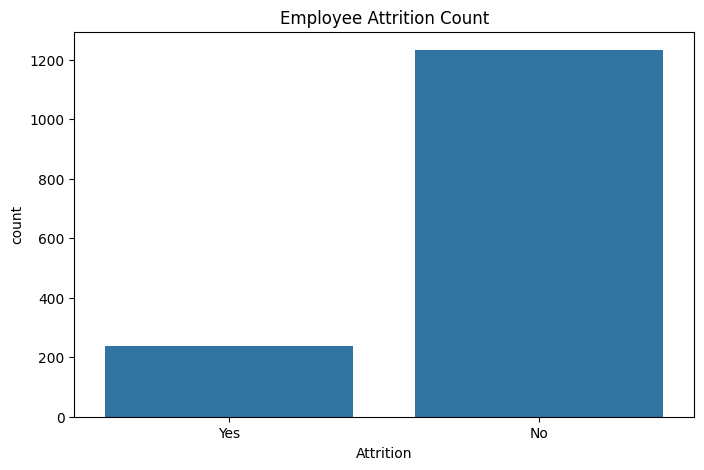

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Count")

plt.savefig("../images/attrition_distribution.png")

plt.show()

In [29]:
df.groupby("Department")["Attrition"].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

### Attrition by Department
This visualization highlights attrition trends across different departments.

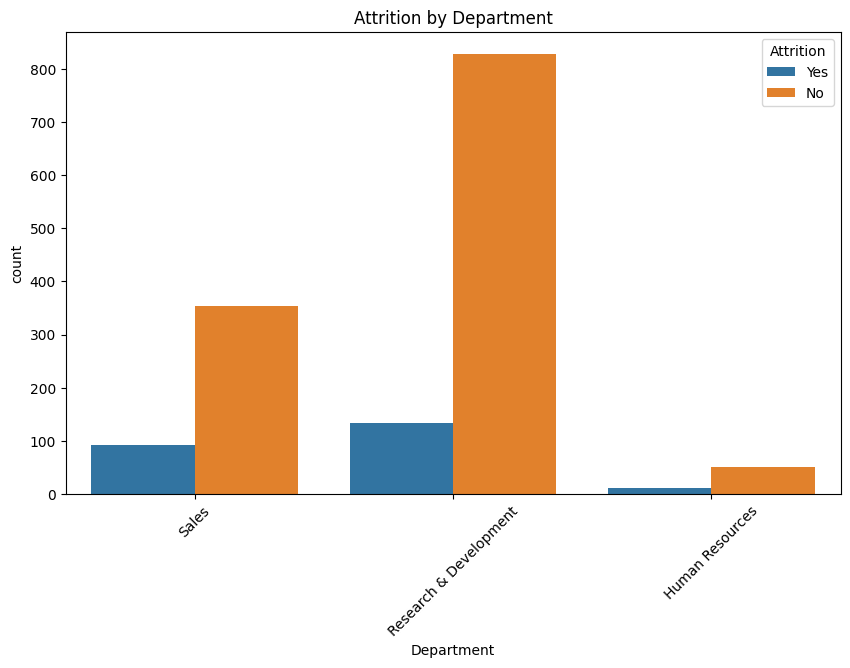

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=45)

plt.savefig("../images/attrition_by_department.png")

plt.show()

### Attrition by Age
This distribution shows how employee age relates to attrition.

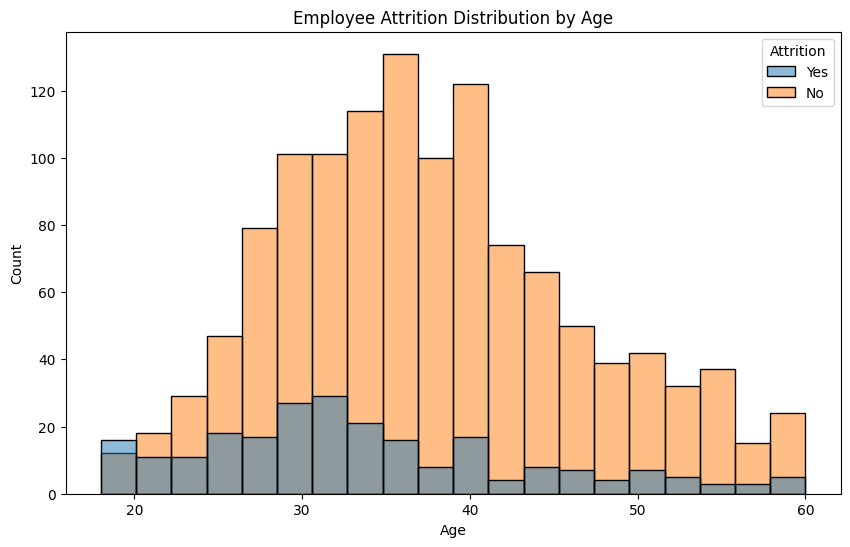

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Age", hue="Attrition", bins=20)
plt.title("Employee Attrition Distribution by Age")

plt.savefig("../images/attrition_by_age.png")

plt.show()

### Monthly Income vs Attrition
This boxplot compares the salary distribution of employees who left versus those who stayed.

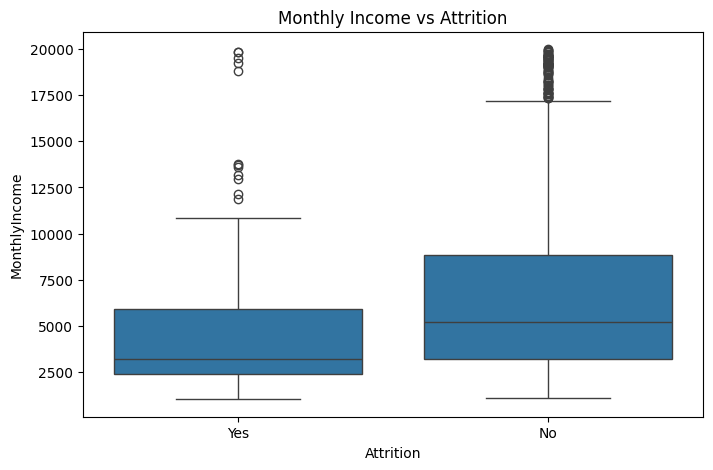

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")

plt.savefig("../images/income_vs_attrition.png")

plt.show()

### Years at Company vs Attrition
This chart shows whether employees with fewer years at the company are more likely to leave.

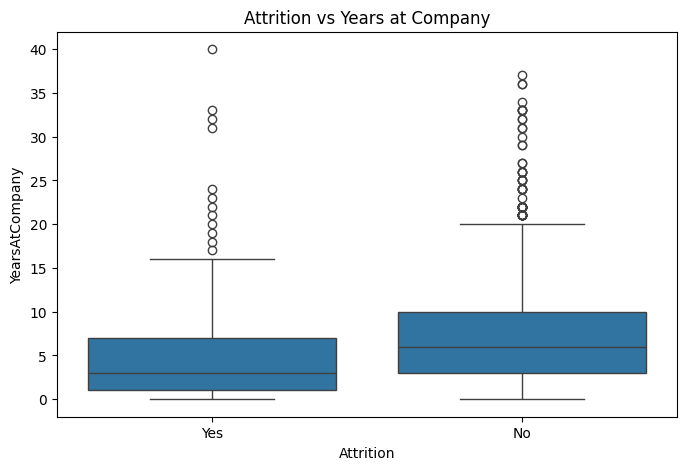

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Attrition vs Years at Company")

plt.savefig("../images/years_vs_attrition.png")

plt.show()

### Attrition by Job Role
This visualization shows which job roles experience higher attrition rates.

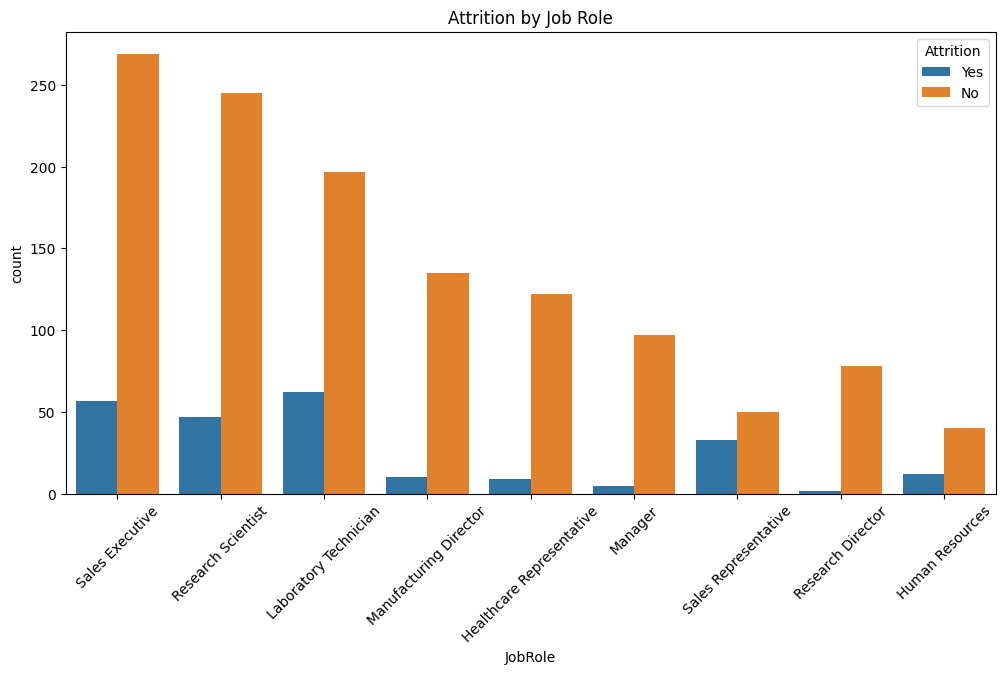

In [34]:
plt.figure(figsize=(12,6))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")

plt.savefig("../images/jobrole_attrition.png")

plt.show()

### Correlation Heatmap
This heatmap shows relationships between numeric variables in the dataset.

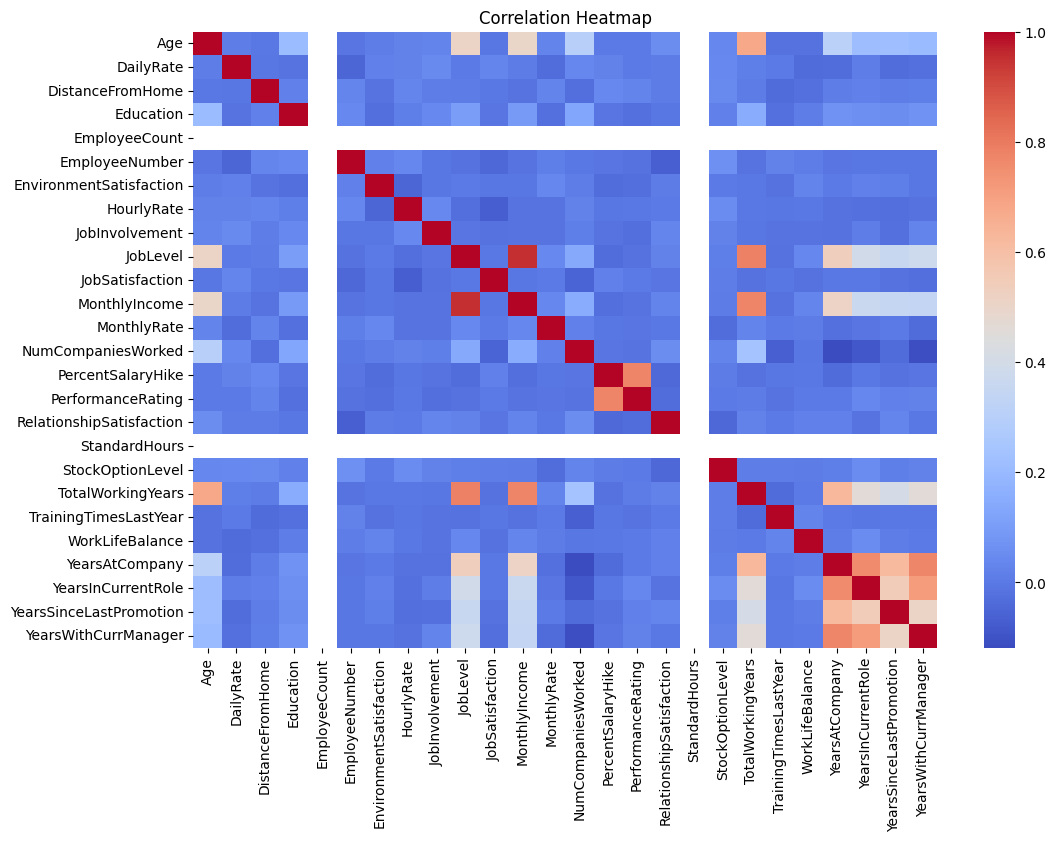

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png")

plt.show()

## 6. Key Insights and Business Implications

1. Overall Attrition
A noticeable portion of employees have left the organization, indicating potential issues with retention strategies.

2. Department Analysis
The Sales department shows the highest attrition compared to other departments, suggesting possible workload or performance pressure.

3. Age Factor
Employees in the younger age group (around 25–35) appear to leave the company more frequently than older employees.

4. Salary Impact
Employees with lower monthly income tend to leave more often, suggesting compensation may influence retention.

5. Years at Company
Employees with fewer years of experience at the company are more likely to leave than long-tenure employees.